<a href="https://colab.research.google.com/github/abhaymaitydatascience/digit-recognizer-project/blob/main/digit-recognizer-project%20/folder%201/digit_recognizer_drabh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100% 15.3M/15.3M [00:00<00:00, 131MB/s] 

Archive:  digit-recognizer.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
 digit-recognizer.zip   sample_data	        test.csv
'kaggle drabh.json'     sample_submission.csv   train.csv


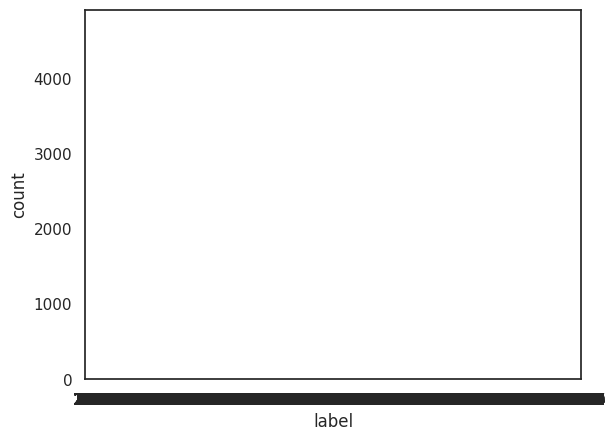

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


439/439 - 278s - 633ms/step - accuracy: 0.8656 - loss: 0.4179 - val_accuracy: 0.9821 - val_loss: 0.0631 - learning_rate: 0.0010


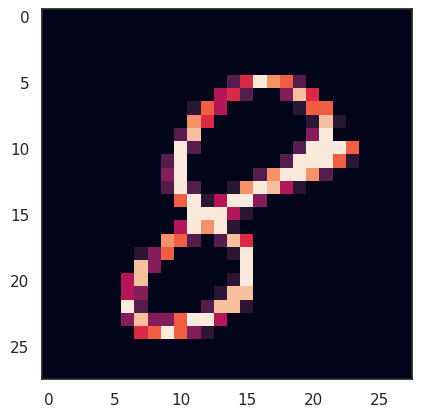

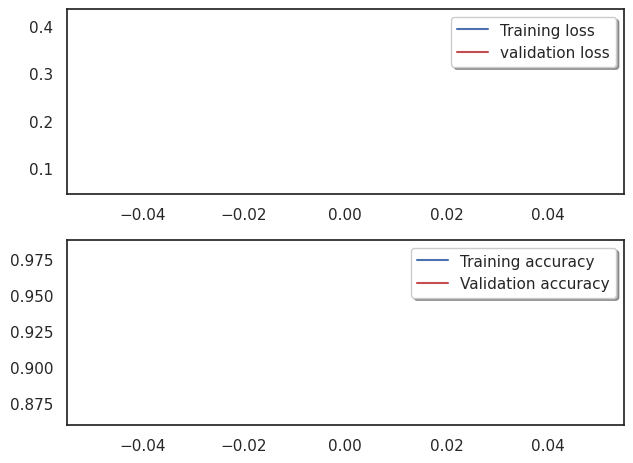

132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step


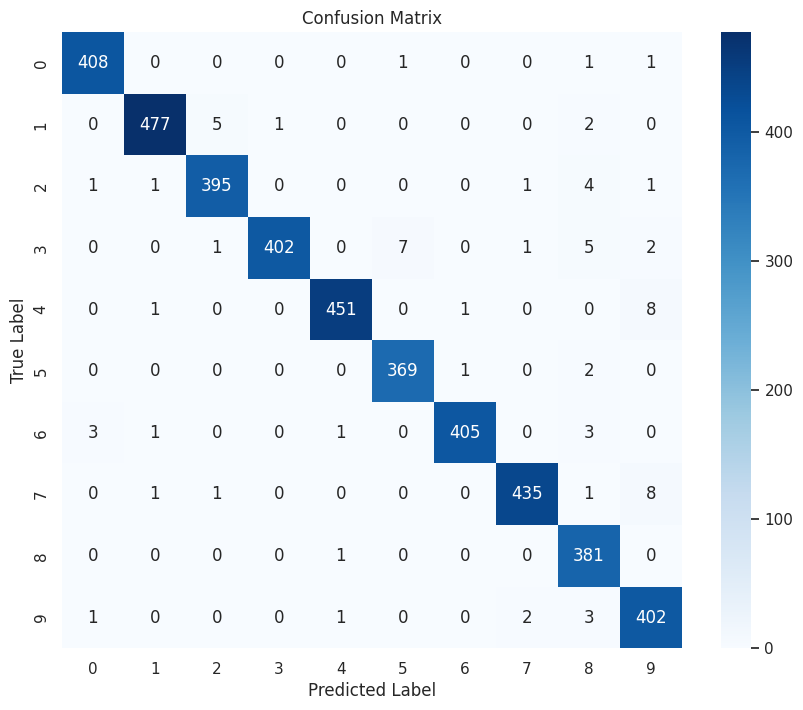

132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step
Overall Accuracy: 0.9821
Weighted F1-Score: 0.9822

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       411
           1       0.99      0.98      0.99       485
           2       0.98      0.98      0.98       403
           3       1.00      0.96      0.98       418
           4       0.99      0.98      0.99       461
           5       0.98      0.99      0.99       372
           6       1.00      0.98      0.99       413
           7       0.99      0.98      0.98       446
           8       0.95      1.00      0.97       382
           9       0.95      0.98      0.97       409

    accuracy                           0.98      4200
   macro avg       0.98      0.98      0.98      4200
weighted avg       0.98      0.98      0.98      4200



In [ ]:
# -*- coding: utf-8 -*-
"""Digit recognizer.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1MsAUu6yn2laOioqdlkY571e8OPLBrU6Y
"""

import os

# Replace 'YOUR_TOKEN_HERE' with the KGAT
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_c3e33a5b1f6d14d5b5fb0930aa5c39ec'

# This downloads the competition files
!kaggle competitions download -c digit-recognizer

# This unzips them so you can see train.csv and test.csv
!unzip digit-recognizer.zip

!ls

# Commented out IPython magic to ensure Python compatibility.
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import itertools
# %matplotlib inline

np.random.seed(2)

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Keras / TensorFlow (Modern Paths)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Use tf.keras path
from tensorflow.keras.callbacks import ReduceLROnPlateau

sns.set(style='white', context='notebook', palette='deep')

# Change the paths to look in the current directory
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

Y_train = train["label"]

# Drop 'label' column
X_train = train.drop(labels = ["label"],axis = 1)

# free some space
del train

g = sns.countplot(Y_train)

Y_train.value_counts()

# Create the plot
sns.countplot(x=Y_train) # It's better to explicitly state x=

# Show the plot
plt.show()

# Display the numerical counts
print(Y_train.value_counts())

# Check the data
X_train.isnull().any().describe()

test.isnull().any().describe()

# 1. Normalize the data (convert pixel values 0-255 to 0-1)
X_train = X_train / 255.0
test = test / 255.0

# 2. Reshape to 28x28 pixels with 1 color channel (grayscale)
X_train = X_train.values.reshape(-1, 28, 28, 1)
test = test.values.reshape(-1, 28, 28, 1)

# 3. One-hot encode the labels (e.g., 2 becomes [0,0,1,0,0,0,0,0,0,0])
Y_train = to_categorical(Y_train, num_classes=10)

# Encode labels to one hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])
Y_train = to_categorical(Y_train, num_classes = 10)

# Set the random seed
random_seed = 2

# Split the train and the validation set for the fitting
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=random_seed)

# Some examples
g = plt.imshow(X_train[0][:,:,0])

# Set the CNN model
# my CNN architechture is In -> [[Conv2D->relu]*2 -> MaxPool2D -> Dropout]*2 -> Flatten -> Dense -> Dropout -> Out

model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',
                 activation ='relu', input_shape = (28,28,1)))
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

# Define the optimizer
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)

# Compile the model
model.compile(optimizer = optimizer ,
              loss = "categorical_crossentropy",
              metrics=["accuracy"])

learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

epochs = 1 # Turn epochs to 30 to get 0.9967 accuracy
batch_size = 86

# With data augmentation to prevent overfitting (accuracy 0.99286)

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(X_train)

# 1. Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# 2. Extract and Encode (ONLY ONCE)
Y_train = train["label"]
X_train = train.drop(labels = ["label"], axis = 1)
# Using the to_categorical function we imported earlier
Y_train = to_categorical(Y_train, num_classes=10)

# 3. Normalize and Reshape
X_train = X_train / 255.0
X_train = X_train.values.reshape(-1, 28, 28, 1)

# 4. Split the data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=2)

# 5. NOW delete train if you need space
del train

# Fit the model
history = model.fit(datagen.flow(X_train, Y_train, batch_size=batch_size),
                              epochs = epochs,
                              validation_data = (X_val, Y_val),
                              verbose = 2,
                              steps_per_epoch = X_train.shape[0] // batch_size,
                              callbacks = [learning_rate_reduction])

# Plot the loss and accuracy curves for training and validation
fig, ax = plt.subplots(2,1)

# Plot Loss
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss") # Removed 'axes=' typo
ax[0].legend(loc='best', shadow=True)

# Plot Accuracy (using modern keys: 'accuracy' and 'val_accuracy')
ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r', label="Validation accuracy")
ax[1].legend(loc='best', shadow=True)

plt.tight_layout() # Prevents subplots from overlapping
plt.show()

# Predict the values from the validation dataset
Y_pred = model.predict(X_val)
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred, axis = 1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(Y_val, axis = 1)
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np

# 1. Get the model's predictions on the validation set
Y_pred = model.predict(X_val)
# Convert predictions from probabilities to class labels (0-9)
Y_pred_classes = np.argmax(Y_pred, axis=1)
# Convert true labels from one-hot encoding back to class labels (0-9)
Y_true = np.argmax(Y_val, axis=1)

# 2. Calculate and print specific metrics
acc = accuracy_score(Y_true, Y_pred_classes)
f1 = f1_score(Y_true, Y_pred_classes, average='weighted')

print(f"Overall Accuracy: {acc:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

# 3. Print the full classification report (Precision, Recall, F1 for each digit)
print("\nDetailed Classification Report:\n")
print(classification_report(Y_true, Y_pred_classes, target_names=[str(i) for i in range(10)]))

